# **Training Notebook**
### 🎯 **Gesture Recognition Application Using Feature Extraction - Assignment #1**

> Ilka BRETSCHNEIDER <br> Romain NOBLET


*Università degli Studi di Trento - 2026*

**Setup environment**

In [11]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow

**Load data and normalization**

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

GESTURES = [
    "punch",
    "flex",
    "rightleft",
    "circle",
]

SAMPLES_PER_GESTURE = 119
NUM_GESTURES = len(GESTURES)
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

def rms(x):
    return np.sqrt(np.mean(np.square(x)))

for gesture_index in range(NUM_GESTURES):
    gesture = GESTURES[gesture_index]
    print(f"Processing index {gesture_index} for gesture '{gesture}'.")

    output = ONE_HOT_ENCODED_GESTURES[gesture_index]
    df = pd.read_csv("/content/" + gesture + ".csv")

    num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)
    print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

    for i in range(num_recordings):

        ax, ay, az = [], [], []
        gx, gy, gz = [], [], []

        for j in range(SAMPLES_PER_GESTURE):
            index = i * SAMPLES_PER_GESTURE + j
            ax.append(df['aX'][index])
            ay.append(df['aY'][index])
            az.append(df['aZ'][index])
            gx.append(df['gX'][index])
            gy.append(df['gY'][index])
            gz.append(df['gZ'][index])

        signals = [
            np.array(ax), np.array(ay), np.array(az),
            np.array(gx), np.array(gy), np.array(gz)
        ]

        # compute raw features: shape (6 signals, 6 feature types)
        # layout matches Arduino: [mean, std, rms, min, max, range] per signal
        raw = np.array([
            [np.mean(s), np.std(s), rms(s), np.min(s), np.max(s), np.max(s)-np.min(s)]
            for s in signals
        ])  # shape (6, 6)

        # normalize each feature type (column) independently across the 6 signals
        # matches Arduino: for each f in 0..5, normalize across signals 0..5
        col_min   = raw.min(axis=0)          # shape (6,)
        col_max   = raw.max(axis=0)          # shape (6,)
        col_range = col_max - col_min
        col_range[col_range < 1e-6] = 1     # avoid division by zero, matches Arduino

        raw_normalized = (raw - col_min) / col_range  # shape (6, 6)

        # flatten row-major to match Arduino memory layout:
        # [mean_ax, std_ax, rms_ax, min_ax, max_ax, range_ax, mean_ay, ...]
        tensor = raw_normalized.flatten()    # shape (36,)

        print(f"Recording {i} features:")
        for idx, val in enumerate(tensor):
            print(f"{idx}: {val:.6f}")
        print("---------------------")

        inputs.append(tensor)
        outputs.append(output)

inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'punch'.
	There are 20 recordings of the punch gesture.
Recording 0 features:
0: 0.098333
1: 0.000000
2: 0.000000
3: 0.997977
4: 0.000000
5: 0.000000
6: 0.012809
7: 0.008953
8: 0.003679
9: 0.983834
10: 0.002085
11: 0.006732
12: 0.200858
13: 0.001612
14: 0.009644
15: 1.000000
16: 0.003522
17: 0.001388
18: 0.000000
19: 1.000000
20: 1.000000
21: 0.057067
22: 0.920773
23: 0.929249
24: 1.000000
25: 0.802984
26: 0.807100
27: 0.000000
28: 1.000000
29: 1.000000
30: 0.626336
31: 0.743917
32: 0.744694
33: 0.064334
34: 0.588938
35: 0.722194
---------------------
Recording 1 features:
0: 0.758003
1: 0.000000
2: 0.000000
3: 0.998406
4: 0.000000
5: 0.000000
6: 0.662749
7: 0.008119
8: 0.003671
9: 0.987161
10: 0.002280
11: 0.006728
12: 0.861999
13: 0.001045
14: 0.007234
15: 1.000000
16: 0.004506
17: 0.001484
18: 0.000000
19: 1.000000
20: 1.000000
21: 0.000000
22: 1.000000
23: 1.000000
24: 0.962278
25: 0.560205
26: 0.558049
27: 0.184306
28: 0.

**Randomize and split the input and output pairs for training**

In [28]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


**Training a NN**

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(inputs.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=200,
    batch_size=8,
    validation_data=(inputs_validate, outputs_validate)
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.5417 - loss: 1.3421 - val_accuracy: 0.2500 - val_loss: 1.3600
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6042 - loss: 1.2730 - val_accuracy: 0.2500 - val_loss: 1.3479
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5625 - loss: 1.2252 - val_accuracy: 0.3750 - val_loss: 1.3234
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6250 - loss: 1.1789 - val_accuracy: 0.3750 - val_loss: 1.2876
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6458 - loss: 1.1316 - val_accuracy: 0.6250 - val_loss: 1.2536
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 1.0808 - val_accuracy: 0.6875 - val_loss: 1.2141
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7292 - loss: 1.0277 - val_accuracy: 0.7500 - val_loss: 1.1669
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7708 - loss: 0.9708 - val_accuracy: 0.8125 - val_loss:

**Model evaluation using accuracy and a confusion matrix**

In [30]:
test_loss, test_acc = model.evaluate(inputs_test, outputs_test)
print("Test accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 5.3465e-04
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


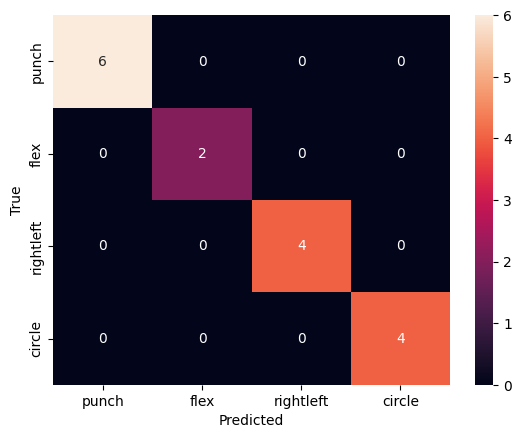

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(inputs_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(outputs_test, axis=1)

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=GESTURES, yticklabels=GESTURES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**The trained model parameters (weights and biases) are exported for deployment on Arduino.**

In [35]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the quantized model to disk
with open("/content/gesture_model_quant.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpgcyq02gh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 36), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136041501399120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501401424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501401232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501407568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501403152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041501401808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136041541078672: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [36]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [37]:
!xxd -i /content/gesture_model_quant.tflite > /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 67,164 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
